# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import graph_tool as gt
from graph_tool.all import *
import copy
from typing import NamedTuple
import matplotlib.pyplot as plt
import random


(ipykernel_launcher.py:31229): dbind-WARNING **: 12:31:14.970: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
class NetworkParams(NamedTuple):
    """NamedTuple class for the parameters of the network."""
    J: np.ndarray          # weight matrix
    C: np.ndarray          # connectivity matrix
    B: np.ndarray          # bias matrix
    G: Graph                # Graph of the network (Graph_tool)
    state: np.ndarray      # values of the cells in the network
    T: np.ndarray   # array of the T functions of the single cells in the network
    N: int = 0              # side lenght of the squared lattice (number of cells = N**2)
    fitness: float = -1.     # fitness value of the network
    
# ORA DEFINISCO LE VARIE FUNZIONI PER OPERARE SUI NETWORK
# - GENERATE(PAR,NETPAR): CREA (IN REALTà NON CREA L'OGGETTO) UN NETWORK RANDOM DATI I PARAMETRI 
#   PAR E RITORNA I PARAMETRI DEL NETWORK (NETPAR) AGGIORNATI
# - COMPUTE_FITNESS(PAR,NETPAR): CALCOLA LA FITNESS DEL NETWORK ATTRAVERSO IL METODO FF() E
#   RITORNA TALE FITNESS.
# - FF(INPUT(S),NETPAR): FA IL 'FEED-FORWARD' DEL NETWORK DATO UN SET DI INPUT E RITORNA 
#   LO STATE (OSSIA L'ARRAY DEGLI STATI 0 O 1 DELLE SINGOLE CELL)
    
def generate(par:dict) -> NetworkParams:  # JAXXED!
#def generate(self,:np.ndarray,N:int,p_self_link:float,N_Fourier:int) -> NetworkParams:  # JAXXED!
    """Generate a random network given the parameters par by updating the 
        NetPar object.

    Args:
        par (dict): simulation/generation parameters.

    Returns:
        NetworkParams: returns the new network's parameters set. 
    """
    N = par['N']  
    C = np.ones((N**2,N**2))                        # as first, initialize C as fully connected (all ones)
    C = C - np.eye(N**2)                                # no self links                                    
    J = nrd.uniform(size=(N**2,N**2)) * C                # uniformly populate the weights in the weight matrix J                                       
    B = nrd.normal(size=(N**2,N**2)) * C                 # extract from a normal distribution centered in 0 with st. dv. = 1 the biases (spero vada bene fatto così)
    G = Graph(np.column_stack(np.nonzero(C)))         # Generate the Graph given the connectivity matrix
    state = np.abs(nrd.normal(size=(N**2,)))        # Randomly assign a state value to each cell distributed as the absolute value of a normal around 0
    f_n = par['T_initial'](par['x_n'])                  # evaluate the initial transfer function on x_n
    T = np.fft.fft(f_n)                                # compute the Fourier coefficients of f_n to move to the frequency space
    T = np.repeat(T,N**2).reshape(N**2,len(par['x_n']))        # each cell of the network at initialization has the same transfer function
    NetPar = NetworkParams(J,C,B,G,state,T,N)              # I don't specify the fitness argument so it stays as default (-1)
    fitness, state = compute_fitness(NetPar,par)                      # Compute the fitness value of the network (also updates the state)
    return NetworkParams(J,C,B,G,state,T,N,fitness)           # return the set of updated parameters

def compute_fitness(NetPar:NetworkParams,par:dict,verb:bool=False) -> tuple[float,np.ndarray]:    # JAXXED!
    """Function for computing the fitness of a given network.

    Args:
        NetPar (NetworkParams): parameter of the network in question.
        par (dict): simulation parameters.
        verb (bool, optional): verbosity. Defaults to False.

    Returns:
        tuple[float,np.ndarray]: computed fitness and updated states of the nodes of the network. 
    """
    fitness = 0.                # I need this check, bc otherwise I risk adding fitness over fitness  
    for i,input in enumerate(par['input_set']):
        output,state = ff(input,NetPar,par)
        if verb:
            print(f'Input: {input} -> {output}')
        norm_factor = NetPar.G.num_vertices()**2-NetPar.G.num_vertices()            # normalize by N(N-1)
        target_dist = (par['target_set'][i] - output)**2                            # square distance between network output and target (theoretical) output
        volume_cost = (np.sum(NetPar.C.reshape(-1))/norm_factor)**2                # average wiring volume cost (i.e. # of links)
        dist = shortest_distance(NetPar.G, directed=True).get_2d_array()            # calculate the shortest path length for each pair of vertecies
        dist = np.where(dist >= 2147483647, 0, dist)                               # set each value that overflows (bc no path exists) to 0
        length_cost = (np.sum((NetPar.C.reshape(-1) * dist.reshape(-1))
                                **par['length_powerlaw'])/norm_factor)**2            # average wiring length cost
        path_cost = (np.sum(dist,axis=(0,1))/norm_factor)**2                       # average shortest path length cost
        if verb:
            print(f'Target distance:{target_dist}')
            print(f'Volume cost:{volume_cost}')
            print(f'Length cost:{length_cost}')
            print(f'Path cost:{path_cost}')
        fitness += np.exp(target_dist + volume_cost + length_cost + path_cost) # take the exponential of the sum of the costs (weighted if needed)
    fitness /= len(par['input_set'])    
    return fitness, state

def ff(input:list,NetPar:NetworkParams,par:dict,verb:int=0) -> tuple[float,np.ndarray]:     # JAXXED!
    """Function to execute the 'feed-forward' computation on a given network, given inputs.

    Args:
        input (list): inputs to the network.
        NetPar (NetworkParams): network in question.
        par (dict): simulation parameters.
        verb (int, optional): verbosity. Defaults to 0.

    Returns:
        tuple[float,np.ndarray]: output of the 'feed-forward' and updated states of each node of the network.
    """
    state = NetPar.state                                # set the value of the two inputs cells through the input value
    state[0] = input[0]                        # cell in the upper left corner of the 2D lattice
    state[(NetPar.N - 1) * NetPar.N-1] = input[1]    # cell in the lower left corner of the 2D lattice
    # Precompute the contributions for each cell to optimize the loop (this is incredibly faster)
    contributions = np.dot(NetPar.C * NetPar.J, state) + np.sum(NetPar.B, axis=1)      # weight x value + bias - contributions così ha shape = state.shape
    # Retrive the T function of each cell by doing ifft and then fit/interpolation
    f_n = np.fft.ifft(NetPar.T,axis=1)      # inverse FT for moving back to coordinates space
    for cell in range(f_n.shape[0]):
        coeff = np.polyfit(par['x_n'],f_n[cell,:],2)    # fit the series of function value with a polynomial of degree up to 2
        new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
        state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell
    if verb > 0: 
        print(f'State of each cell: {state}')
    output = state[-1]                          # the cell in the right lower corner is the output
    return output, state

In [3]:
############# GENETIC ALGORITHM #################
def crossover(par1:NetworkParams,par2:NetworkParams) -> tuple[NetworkParams,NetworkParams]:
    """Function to generate 2 offsprings from 2 parents by crossover ricombination.

    Args:
        par1 (NetworkParams): parent network #1.
        par2 (NetworkParams): parent network #2.

    Returns:
        tuple[NetworkParams,NetworkParams]: pair of offsprings.
    """   
    # Implements the crossover ricombination given 2 parent NetworkParams
    # and returns 2 offspring NetworksParams.
    if par1.C.shape != par2.C.shape:
        print(f'Error: length mismatch between the connectivity matrices of the two parents! Got parent1={par1.C.shape} and parent2={par2.C.shape}')
        raise ValueError
    if par1.T.shape != par2.T.shape:
        print(f'Error: length mismatch between the T matrices of the two parents! Got parent1={par1.T.shape} and parent2={par2.T.shape}')
        raise ValueError
    # First, I do C crossover
    cut_idx = nrd.choice(np.arange(len(par1.C)))  # randomly pick where to cut the chromosomes
    C1 = np.append(par1.C.reshape(-1)[:cut_idx],par2.C.reshape(-1)[cut_idx:]).reshape(par1.C.shape)      # create the new C matrices by crossover
    C1 = C1 - np.eye(par1.N**2)                                                                             # eliminate possible self links
    C2 = np.append(par2.C.reshape(-1)[:cut_idx],par1.C.reshape(-1)[cut_idx:]).reshape(par1.C.shape)
    C2 = C2 - np.eye(par2.N**2)                                                                             # eliminate possible self links
    J1 = np.append(par1.J.reshape(-1)[:cut_idx],par2.J.reshape(-1)[cut_idx:]).reshape(par1.J.shape)      # create the new J matrices by crossover
    J2 = np.append(par2.J.reshape(-1)[:cut_idx],par1.J.reshape(-1)[cut_idx:]).reshape(par1.J.shape)
    J1 *= C1        # eliminate the weights for non existing links
    J2 *= C2
    B1 = np.append(par1.B.reshape(-1)[:cut_idx],par2.B.reshape(-1)[cut_idx:]).reshape(par1.B.shape)      # create the new B matrices by crossover
    B2 = np.append(par2.B.reshape(-1)[:cut_idx],par1.B.reshape(-1)[cut_idx:]).reshape(par1.B.shape)
    B1 *= C1        # eliminate the biases for non existing links
    B2 *= C2
    # Now T crossover
    cut_idx = nrd.choice(np.arange(par1.T.shape[1]),par1.T.shape[0])  # randomly pick where to cut each cell's T coefficients string
    T1 = np.zeros((par1.T.shape))
    T2 = np.zeros((par1.T.shape))
    for cell in range(par1.T.shape[0]):      # I have to use this loop because append only works with one dimensional arrays
        T1[cell,:] = np.append(par1.T[cell,:cut_idx[cell]],par2.T[cell,cut_idx[cell]:])
        T2[cell,:] = np.append(par2.T[cell,:cut_idx[cell]],par1.T[cell,cut_idx[cell]:])
    # Now I set the other elements of NetPar that are not affected by the crossover
    state1 = np.abs(nrd.normal(size=par1.state.shape))     # State distributed as in the initialization because, biologically,
    state2 = np.abs(nrd.normal(size=par1.state.shape))     # it makes sense that the children do not inherit the value of the neurons of the parents
    G1 = Graph(np.column_stack(np.nonzero(C1)))                       # Generate the Graph given the connectivity matrix
    G2 = Graph(np.column_stack(np.nonzero(C2)))      
    # LE PROSSIME RIGHE SONO COMMENTATE PERCHé PER ORA NON MI SERVE CHE QUESTA FUNZIONE CALCOLI ANCHE LA FITNESS, PERCHé
    # LO FA LA FUNZIONE MUTATION, CHE PER ORA VIENE SEMPRE ESEGUITA UNA VOLTA CHE VIENE ESEGUITA QUESTA                 
    #NetPar1 = NetworkParams(J1,C1,B1,G1,state1,T1,par1.N)
    #NetPar2 = NetworkParams(J2,C2,B2,G2,state2,T2,par1.N)
    #fitness1, state1 = compute_fitness(par,NetPar1)
    #fitness2, state2 = compute_fitness(par,NetPar2)
    #return [NetworkParams(J1,C1,B1,G1,state1,T1,par1.N,fitness1), NetworkParams(J2,C2,B2,G2,state2,T2,par1.N,fitness2)]
    return (NetworkParams(J1,C1,B1,G1,state1,T1,par1.N), NetworkParams(J2,C2,B2,G2,state2,T2,par1.N))
    
def mutation(n:NetworkParams,par:dict) -> NetworkParams:
    """Function to mutate a given network.

    Args:
        n (NetworkParams): parameters of the network to mutate.
        par (dict): simulation parameters.

    Returns:
        NetworkParams: mutated parameters of the network
    """
    # Function to mutate a given network
    ## Mutate C (probability of link inversly proportional to the length of the link)
    idx = np.arange(par['N']**2)
    row_idx = idx // par['N']
    col_idx = idx % par['N']
    row_diff = row_idx[:, None] - row_idx[None, :]
    col_diff = col_idx[:, None] - col_idx[None, :]
    dist_matrix = np.sqrt(row_diff**2 + col_diff**2)
    prob_matrix = np.where(np.eye(par['N']**2, dtype=bool),  # Create the probability matrix for connectivity
        par['p_self_link'],1/dist_matrix)
    mutationC = np.where(nrd.binomial(n=1,p=np.array(prob_matrix)),1,0)    # Generate C (binomial distribution with n=1 is the Bernoulli distribution) 
    C_m = n.C * mutationC   # Apply the mutation
    ## Mutate J
    mutationJ = par['J_mutation_radius']*nrd.normal(size=n.J.shape)   # mutation as gaussian noise (I multiply for the sd 
                                                                            # bc JAX only gives the unit normal)                                                                      
    J_m = C_m * (n.J + mutationJ)        # Apply the mutation and eliminate weights for non existing links
    J_m = np.clip(J_m, min(par['J_range']), max(par['J_range']))   # Check the boundary conditions for J
    ## Mutate B
    mutationB = par['B_mutation_radius']*nrd.normal(size=n.B.shape)   # mutation as gaussian noise (I multiply for the sd 
                                                                            # bc JAX only gives the unit normal)
    B_m = C_m * (n.B + mutationB)        # Apply the mutation and eliminate biases for non existing links
    # Mutate the T function
    mutationT = par['T_mutation_radius']*nrd.normal(size=n.T.shape)   # mutation as gaussian noise (I multiply for the sd 
                                                                            # bc JAX only gives the unit normal)
    T_m = n.T + mutationT        # Apply the mutation 
    G_m = Graph(np.column_stack(np.nonzero(C_m)))     # create a new graph given the mutations
    NetPar = NetworkParams(J_m,C_m,B_m,G_m,n.state,T_m,n.N)
    fitness_m, state_m = compute_fitness(NetPar,par)
    return NetworkParams(J_m,C_m,B_m,G_m,state_m,T_m,n.N,fitness_m)

def evolution(par:dict,verb:int=1,early_stop:bool=True) -> tuple[list,list]:
    """Genetic algolrithm for evolving a network population (both the networks and the single nodes).

    Args:
        par (dict): simulation parameters.
        verb (int, optional): verbosity. Defaults to 1.
        early_stop (bool, optional): early stopping condition. Defaults to True.

    Raises:
        ValueError: returns an error if par['N_sol'] is not even.
        ValueError: returns an error if the population is not conserved from one generation to the next.

    Returns:
        tuple[list,list]: offsprings list and mean fitness values list.
    """
    if par['N_sol'] % 2 != 0:     # N_sol must be even
        print(f'Error:The number of solutions N_sol must be an even positive number.')
        raise ValueError
    solutions = []              # Generate the initial batch of solutions
    for n in range(par['N_sol']):
        # Generate a solution
        sol = generate(par)     # already computes also the fitness value
        solutions.append(sol)
    Fmean_values = []               # Initiate some container for statistic
    
    ##  EVOLUTION
    for iter in range(par['n_iter']):
        # Compute the mean fitness for statistics
        mean_fit = np.sum(np.array([sol.fitness for sol in solutions])) / par['N_sol']    # Here I don't have to divide also by 4, because I've already done it in the compute_fitness method
        # Save the old solution set for possible early stopping (QUESTO DOVREBBE TRIGGERARE SOLO SE SIAMO IN EARLY STOPPING IN QUESTA ITERAZIONE)
        '''
        if early_stop:
            solutions_old = []
            for sol in solutions:
                solutions_old.append(copy.deepcopy(sol))
        '''
        # SELECTION
        solutions = sorted(solutions, key=lambda sol: sol.fitness)    # sort in ascending order based on fitness
        n_parents = int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)  # the 2nd floor assures that n_parents is even
        parents_idx = nrd.choice(np.arange(par['N_sol']),
                                 size=(int(n_parents/2),2),replace=True,
                                 p=np.array([1/sol.fitness for sol in solutions])
                                 /np.sum(np.array([1/sol.fitness for sol in solutions])))
        # REPRODUCTION
        offsprings = []
        for pair in range(len(parents_idx)):
            offspring = crossover(solutions[parents_idx[pair,0]],solutions[parents_idx[pair,1]])    # generate 2 offspring by crossover
            offspring0 = mutation(offspring[0],par)     # mutate them
            offsprings.append(offspring0)          # add them to the new population
            offspring1 = mutation(offspring[1],par)
            offsprings.append(offspring1)          # add them to the new population
        if iter%100 == 0 and verb == 1:
            print(f'Iteration #{iter}...')
            print(f'# of childs: {len(offspring)}')
        elif iter%10 == 0 and verb == 2:
            print(f'Iteration #{iter}...')
            print(f'# of childs: {len(offspring)}')
        elif verb == 3: 
            print(f'Iteration #{iter}...')
            print(f'# of childs: {len(offspring)}')
        # RANDOM GENERATION
        for _ in range(par['N_sol']-n_parents):
            sol = generate(par)
            offsprings.append(sol)
        if len(offsprings) != par['N_sol']:      # check population conservation
            print(f'Error: population not conserved; mismatching number of individuals between old and new populations. Got {len(offsprings)}, expected {par['N_sol']}')
            raise ValueError
        random.shuffle(offsprings)     # shuffle the new population for good measure
        Fmean_values.append(mean_fit)   # statistics
    return offsprings, Fmean_values
        
########## UTILITY FUNCTIONS #################
def plot_T(T:np.ndarray,par:dict) -> None:
    f_n = np.fft.ifft(T)
    coeff = np.polyfit(par['x_n'],f_n,2)    # fit the series of function value with a polynomial of degree up to 5
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.arange(min(par['x_n']),max(par['x_n']),1000)
    plt.plot(x,new_fun(x))
    plt.show()
        
        
        

In [4]:
# parameters of the simulation
par={'N': 2,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0.5,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.1,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.1,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'length_powerlaw': 1,         # exponent of the wire length power law (DA DEFINIRE!!!)
     'x_n': np.linspace(-1,1,20),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0 + 1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 10,
     'N_sol': 10}                       # number of solutions (individuals, networks) considered in the simulation

nrd.seed(1234)

In [5]:
solutions = []              # Generate the initial batch of solutions
# Generate a solution
sol = generate(par)     # already computes also the fitness value
solutions.append(sol)
print([sol.fitness for sol in solutions])
np.array([1/sol.fitness for sol in solutions])/np.sum(np.array([sol.fitness for sol in solutions]))

/tmp/ipykernel_31229/2864802733.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell


[100.14436537509178]


array([9.97118933e-05])

In [7]:
sol, fmean = evolution(par,verb=3)

/tmp/ipykernel_31229/2864802733.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell
/tmp/ipykernel_31229/3709478495.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  T1[cell,:] = np.append(par1.T[cell,:cut_idx[cell]],par2.T[cell,cut_idx[cell]:])
/tmp/ipykernel_31229/3709478495.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  T2[cell,:] = np.append(par2.T[cell,:cut_idx[cell]],par1.T[cell,cut_idx[cell]:])
/tmp/ipykernel_31229/3709478495.py:74: RuntimeWarning: divide by zero encountered in divide
  par['p_self_link'],1/dist_matrix)


Iteration #0...
# of childs: 2
Iteration #1...
# of childs: 2
Iteration #2...
# of childs: 2
Iteration #3...
# of childs: 2
Iteration #4...
# of childs: 2
Iteration #5...
# of childs: 2
Iteration #6...
# of childs: 2
Iteration #7...
# of childs: 2
Iteration #8...
# of childs: 2
Iteration #9...
# of childs: 2


In [8]:
n1 = generate(par)
n2 = generate(par)

o1, o2 = crossover(n1,n2)

/tmp/ipykernel_31229/2864802733.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell
/tmp/ipykernel_31229/3709478495.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  T1[cell,:] = np.append(par1.T[cell,:cut_idx[cell]],par2.T[cell,cut_idx[cell]:])
/tmp/ipykernel_31229/3709478495.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  T2[cell,:] = np.append(par2.T[cell,:cut_idx[cell]],par1.T[cell,cut_idx[cell]:])


In [9]:
class NetworkParams(NamedTuple):
    """NamedTuple class for the parameters of the network."""
    J: np.ndarray          # weight matrix
    C: np.ndarray          # connectivity matrix
    B: np.ndarray          # bias matrix
    G: Graph                # Graph of the network (Graph_tool)
    state: np.ndarray      # values of the cells in the network
    T: np.ndarray   # array of the T functions of the single cells in the network
    N: int = 0              # side lenght of the squared lattice (number of cells = N**2)
    fitness: float = -1.     # fitness value of the network
    
# ORA DEFINISCO LE VARIE FUNZIONI PER OPERARE SUI NETWORK
# - GENERATE(PAR,NETPAR): CREA (IN REALTà NON CREA L'OGGETTO) UN NETWORK RANDOM DATI I PARAMETRI 
#   PAR E RITORNA I PARAMETRI DEL NETWORK (NETPAR) AGGIORNATI
# - COMPUTE_FITNESS(PAR,NETPAR): CALCOLA LA FITNESS DEL NETWORK ATTRAVERSO IL METODO FF() E
#   RITORNA TALE FITNESS.
# - FF(INPUT(S),NETPAR): FA IL 'FEED-FORWARD' DEL NETWORK DATO UN SET DI INPUT E RITORNA 
#   LO STATE (OSSIA L'ARRAY DEGLI STATI 0 O 1 DELLE SINGOLE CELL)
    
def generate(par:dict) -> NetworkParams:  # JAXXED!
#def generate(self,:np.ndarray,N:int,p_self_link:float,N_Fourier:int) -> NetworkParams:  # JAXXED!
    """Generate a random network given the parameters par by updating the 
        NetPar object.

    Args:
        par (dict): simulation/generation parameters.

    Returns:
        NetworkParams: returns the new network's parameters set. 
    """
    N = par['N']  
    C = np.ones((N**2,N**2))                        # as first, initialize C as fully connected (all ones)
    C = C - np.eye(N**2)                                # no self links                                    
    J = nrd.uniform(size=(N**2,N**2)) * C                # uniformly populate the weights in the weight matrix J                                       
    B = nrd.normal(size=(N**2,N**2)) * C                 # extract from a normal distribution centered in 0 with st. dv. = 1 the biases (spero vada bene fatto così)
    G = Graph(np.column_stack(np.nonzero(C)))         # Generate the Graph given the connectivity matrix
    state = np.abs(nrd.normal(size=(N**2,)))        # Randomly assign a state value to each cell distributed as the absolute value of a normal around 0
    f_n = par['T_initial'](par['x_n'])                  # evaluate the initial transfer function on x_n
    T = np.fft.fft(f_n)                                # compute the Fourier coefficients of f_n to move to the frequency space
    T = np.repeat(T,N**2).reshape(N**2,len(par['x_n']))        # each cell of the network at initialization has the same transfer function
    NetPar = NetworkParams(J,C,B,G,state,T,N)              # I don't specify the fitness argument so it stays as default (-1)
    fitness, state = compute_fitness(NetPar,par,verb=True)                      # Compute the fitness value of the network (also updates the state)
    return NetworkParams(J,C,B,G,state,T,N,fitness)           # return the set of updated parameters

def compute_fitness(NetPar:NetworkParams,par:dict,verb:bool=False) -> tuple[float,np.ndarray]:    # JAXXED!
    """Function for computing the fitness of a given network.

    Args:
        NetPar (NetworkParams): parameter of the network in question.
        par (dict): simulation parameters.
        verb (bool, optional): verbosity. Defaults to False.

    Returns:
        tuple[float,np.ndarray]: computed fitness and updated states of the nodes of the network. 
    """
    fitness = 0.                # I need this check, bc otherwise I risk adding fitness over fitness  
    for i,input in enumerate(par['input_set']):
        output,state = ff(input,NetPar,par)
        if verb:
            print(f'Input: {input} -> {output}')
        norm_factor = NetPar.G.num_vertices()**2-NetPar.G.num_vertices()            # normalize by N(N-1)
        target_dist = (par['target_set'][i] - output)**2                            # square distance between network output and target (theoretical) output
        volume_cost = (np.sum(NetPar.C.reshape(-1))/norm_factor)**2                # average wiring volume cost (i.e. # of links)
        dist = shortest_distance(NetPar.G, directed=True).get_2d_array()            # calculate the shortest path length for each pair of vertecies
        dist = np.where(dist >= 2147483647, 0, dist)                               # set each value that overflows (bc no path exists) to 0
        length_cost = (np.sum((NetPar.C.reshape(-1) * dist.reshape(-1))
                                **par['length_powerlaw'])/norm_factor)**2            # average wiring length cost
        path_cost = (np.sum(dist,axis=(0,1))/norm_factor)**2                       # average shortest path length cost
        if verb:
            print(f'Target distance:{target_dist}')
            print(f'Volume cost:{volume_cost}')
            print(f'Length cost:{length_cost}')
            print(f'Path cost:{path_cost}')
        fitness += np.exp(target_dist + volume_cost + length_cost + path_cost) # take the exponential of the sum of the costs (weighted if needed)
        print(f'Fitness: {fitness}')
    fitness /= len(par['input_set'])    
    return fitness, state

def ff(input:list,NetPar:NetworkParams,par:dict,verb:int=0) -> tuple[float,np.ndarray]:     # JAXXED!
    """Function to execute the 'feed-forward' computation on a given network, given inputs.

    Args:
        input (list): inputs to the network.
        NetPar (NetworkParams): network in question.
        par (dict): simulation parameters.
        verb (int, optional): verbosity. Defaults to 0.

    Returns:
        tuple[float,np.ndarray]: output of the 'feed-forward' and updated states of each node of the network.
    """
    state = NetPar.state                                # set the value of the two inputs cells through the input value
    state[0] = input[0]                        # cell in the upper left corner of the 2D lattice
    state[(NetPar.N - 1) * NetPar.N-1] = input[1]    # cell in the lower left corner of the 2D lattice
    # Precompute the contributions for each cell to optimize the loop (this is incredibly faster)
    contributions = np.dot(NetPar.C * NetPar.J, state) + np.sum(NetPar.B, axis=1)      # weight x value + bias - contributions così ha shape = state.shape
    # Retrive the T function of each cell by doing ifft and then fit/interpolation
    f_n = np.fft.ifft(NetPar.T,axis=1)      # inverse FT for moving back to coordinates space
    print(f'f_n:{f_n.shape}')
    for cell in range(f_n.shape[0]):
        coeff = np.polyfit(par['x_n'],f_n[cell,:],2)    # fit the series of function value with a polynomial of degree up to 2
        new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
        state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell
    if verb > 0: 
        print(f'State of each cell: {state}')
    output = state[-1]                          # the cell in the right lower corner is the output
    return output, state

In [10]:
solutions = []              # Generate the initial batch of solutions
# Generate a solution
sol = generate(par)     # already computes also the fitness value
solutions.append(sol)
print([sol.fitness for sol in solutions])
np.array([1/sol.fitness for sol in solutions])/np.sum(np.array([sol.fitness for sol in solutions]))

f_n:(4, 20)
Input: [0, 0] -> -1.617718960961742
Target distance:2.617014636655138
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 275.0669813778134
f_n:(4, 20)
Input: [0, 1] -> -1.4224554135417184
Target distance:5.868290230597578
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 7378.192859016342
f_n:(4, 20)
Input: [1, 0] -> -1.4806984476807865
Target distance:6.153864788325864
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 16829.088457522448
f_n:(4, 20)
Input: [1, 1] -> -1.2204980400469885
Target distance:1.4896154657585403
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 16918.175639741716
[4229.543909935429]


/tmp/ipykernel_31229/3257811880.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell


array([5.59001436e-08])

In [11]:
def plot_T(T:np.ndarray,par:dict) -> None:
    f_n = np.fft.ifft(T)
    print(f'f_n: {f_n}')
    coeff = np.polyfit(par['x_n'],f_n,2)    # fit the series of function value with a polynomial of degree up to 5
    print(f'Coeff: {coeff}')
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.linspace(min(par['x_n']),max(par['x_n']),1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()

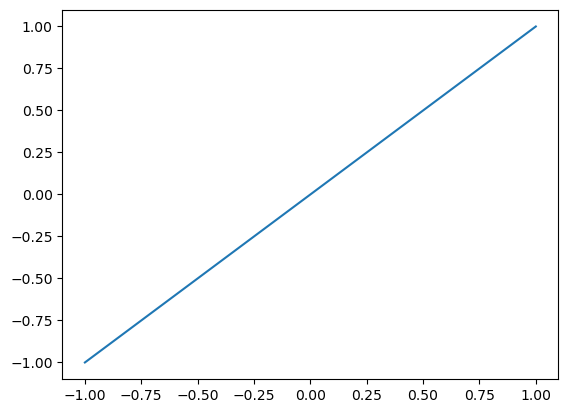

In [12]:
plt.plot(par['x_n'],par['T_initial'](par['x_n']))

In [13]:
f_n = par['T_initial'](par['x_n'])
c_n = np.fft.fft(f_n)
print(c_n)

[-9.99200722e-16+0.00000000e+00j -1.05263158e+00+6.64605423e+00j
 -1.05263158e+00+3.23966688e+00j -1.05263158e+00+2.06590580e+00j
 -1.05263158e+00+1.44882307e+00j -1.05263158e+00+1.05263158e+00j
 -1.05263158e+00+7.64781608e-01j -1.05263158e+00+5.36342578e-01j
 -1.05263158e+00+3.42020733e-01j -1.05263158e+00+1.66720463e-01j
 -1.05263158e+00-2.22044605e-16j -1.05263158e+00-1.66720463e-01j
 -1.05263158e+00-3.42020733e-01j -1.05263158e+00-5.36342578e-01j
 -1.05263158e+00-7.64781608e-01j -1.05263158e+00-1.05263158e+00j
 -1.05263158e+00-1.44882307e+00j -1.05263158e+00-2.06590580e+00j
 -1.05263158e+00-3.23966688e+00j -1.05263158e+00-6.64605423e+00j]


[-1.        +0.00000000e+00j -0.89473684+0.00000000e+00j
 -0.78947368+3.33066907e-17j -0.68421053-3.33066907e-17j
 -0.57894737-1.66204721e-17j -0.47368421-3.46365105e-18j
 -0.36842105-4.56332983e-17j -0.26315789+7.31327109e-17j
 -0.15789474-2.27581942e-17j -0.05263158+1.50867418e-17j
  0.05263158-2.32258647e-17j  0.15789474-4.48562747e-17j
  0.26315789-1.07228982e-16j  0.36842105+9.95575292e-17j
  0.47368421-5.54908345e-17j  0.57894737+3.96145126e-17j
  0.68421053+3.55853455e-17j  0.78947368-5.56694687e-17j
  0.89473684+9.10433067e-17j  1.        +2.09268932e-17j]


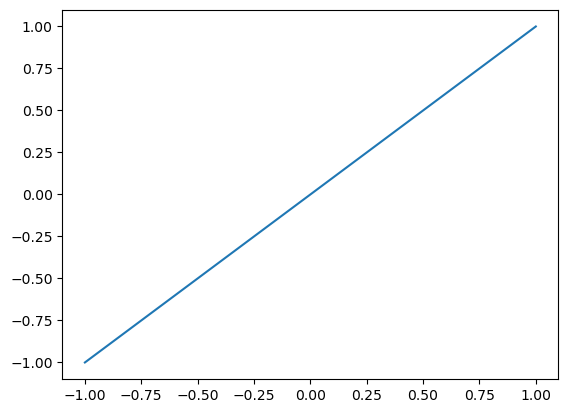

In [14]:
f_n = par['T_initial'](par['x_n'])
c_n = np.fft.fft(f_n)
fn_new = np.fft.ifft(c_n)
print(fn_new)
coeff = np.polyfit(par['x_n'],f_n,2)
new_fun = np.poly1d(coeff)
plt.plot(par['x_n'],new_fun(par['x_n']))

f_n: [-8.42105263e-01+2.68009000e+00j -6.13941712e-01-6.90419873e-01j
  5.31061576e-01-5.54349128e-01j  5.56909846e-01+2.29007422e-01j
 -1.81356061e-02+3.45580271e-01j  0.00000000e+00+4.44089210e-17j
 -1.78343711e-01-1.04567623e-02j -5.71097575e-03-2.66183164e-01j
  2.65278634e-01-1.10680234e-01j  1.37791263e-01+1.53054471e-01j
  0.00000000e+00+2.77555756e-18j -1.09351765e-01+9.72388144e-02j
 -1.80118950e-01-1.72552366e-01j  1.16685109e-01-2.83759740e-01j
  2.51078764e-01+1.31762891e-02j  6.66133815e-17+0.00000000e+00j
 -1.43924985e-02+2.45469059e-01j -5.22413873e-01+1.12084210e-02j
 -3.40638734e-01-8.16443684e-01j  9.66347897e-01-8.69979793e-01j]
Coeff: [-0.16112718+0.24864972j  0.12977413-0.46823876j  0.05936265-0.09160779j]


/home/pietromalagoli/miniconda3/envs/uni/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/pietromalagoli/miniconda3/envs/uni/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


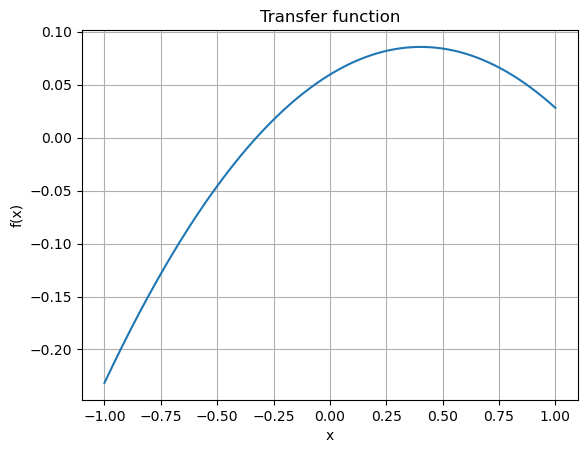

In [15]:
plot_T(sol.T[0,:],par)

In [16]:
#### EXECUTION
# Generate random keys
sol, Fmean = evolution(par,verb=1)

f_n:(4, 20)
Input: [0, 0] -> 0.9781543162694369
Target distance:0.9567858664365296
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 52.288991766306374
f_n:(4, 20)
Input: [0, 1] -> 0.9859221660976056
Target distance:0.00019818540738340417
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 72.37850974429213
f_n:(4, 20)
Input: [1, 0] -> 0.9614305534780924
Target distance:0.001487602205006293
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 92.49394819176796
f_n:(4, 20)
Input: [1, 1] -> 0.9758968177855701
Target distance:0.9523745989640022
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 144.5527872353512
f_n:(4, 20)
Input: [0, 0] -> 0.42827300139451163
Target distance:0.18341776372346336
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 24.129080280535888
f_n:(4, 20)
Input: [0, 1] -> 0.20858537752344514
Target distance:0.6263371046697078
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 61.70401148192629
f_n:(4, 20)
Input: [1, 0] -> 0.40173227364687153
Targ

/tmp/ipykernel_31229/3257811880.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell
/tmp/ipykernel_31229/3709478495.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  T1[cell,:] = np.append(par1.T[cell,:cut_idx[cell]],par2.T[cell,cut_idx[cell]:])
/tmp/ipykernel_31229/3709478495.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  T2[cell,:] = np.append(par2.T[cell,:cut_idx[cell]],par1.T[cell,cut_idx[cell]:])
/tmp/ipykernel_31229/3709478495.py:74: RuntimeWarning: divide by zero encountered in divide
  par['p_self_link'],1/dist_matrix)


f_n:(4, 20)
Fitness: 14.955557516816553
f_n:(4, 20)
Fitness: 50.53058592417531
f_n:(4, 20)
Fitness: 95.68698133789066
f_n:(4, 20)
Fitness: 110.5705453360521
f_n:(4, 20)
Fitness: 14.875134582509983
f_n:(4, 20)
Fitness: 52.98666899133721
f_n:(4, 20)
Fitness: 106.79591065196047
f_n:(4, 20)
Fitness: 121.03304441454134
f_n:(4, 20)
Fitness: 73.62704660435543
f_n:(4, 20)
Fitness: 105.56269444187545
f_n:(4, 20)
Fitness: 142.50101425079865
f_n:(4, 20)
Fitness: 157.61791222963666
f_n:(4, 20)
Fitness: 17.647699709771945
f_n:(4, 20)
Fitness: 59.883247969071874
f_n:(4, 20)
Fitness: 108.34218775135186
f_n:(4, 20)
Fitness: 125.94791598897092
f_n:(4, 20)
Input: [0, 0] -> 0.07427163384019354
Target distance:0.005516275593291783
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 20.196640437363662
f_n:(4, 20)
Input: [0, 1] -> 0.20238962859797588
Target distance:0.6361823045680749
Volume cost:1.0
Length cost:1.0
Path cost:1.0
Fitness: 58.14333136920818
f_n:(4, 20)
Input: [1, 0] -> 0.2742128976556361
